# [0.1] DESI Data: Import to HATS

In [ ]:

import os
from pathlib import Path

import lsdb
import matplotlib.pyplot as plt
import nested_pandas as npd
import numpy as np
import pandas as pd
import pyarrow as pa
from astropy.io import fits
from astropy.table import Table, join
from dask.distributed import Client
from hats.io.validation import is_valid_catalog
from hats_import.catalog.arguments import ImportArguments
from hats_import.catalog.file_readers import InputReader
from hats_import.pipeline import pipeline_with_client

/global/homes/o/olynn/.venvs/p312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
main_directory = Path("/global/cfs/cdirs/desi/public/dr1/spectro/redux/iron")
core_redshift_catalog = main_directory / "zcatalog/v1/zall-pix-iron.fits"
spectra_directory = main_directory / "healpix/"

## Set up

**Where will the product live?** 
- Unsure. 
- In my notes' Background section, I mention a USDF dir `/sdf/data/rubin/cosmicdata/lsdb` where we want to "transfer (nearly) all HATS catalogs that are on data.lsdb.io". But, right now we're on NERSC, not USDF
- In Stephen Bailey's email, he mentions two dirs:
    - `/global/cfs/cdirs/cosmo/users/` for testing (make your own user dir here)
    - `/global/cfs/cdirs/cosmo/www/users/` for dir you want to make web visible

Let's target the dir that Stephen talked about, especially for this initial subset. And recall, we have an honor-system imposed 50TB limit here.

In [3]:
users_dir = Path("/global/cfs/cdirs/cosmo/users/")
target_user_dir = users_dir / "olynn"
os.makedirs(target_user_dir, exist_ok=True)

! tree -L 2 $users_dir

/global/cfs/cdirs/cosmo/users
├── cosmo
│   ├── archive_unwise_neo11.log
│   └── archive_unwise_neo9.log
├── olynn
├── sjbailey
│   ├── dev
│   └── git
└── xiangchl
    ├── DP1
    ├── pdr3_dud_rev
    └── pdr3_wide

9 directories, 2 files


In [4]:
# Set up paths and arguments for the HATS import pipeline run.

base_path = spectra_directory
output_path = target_user_dir

print(f"Base path for input files: {base_path}")
print(f"Output path for HATS import: {output_path}")

Base path for input files: /global/cfs/cdirs/desi/public/dr1/spectro/redux/iron/healpix
Output path for HATS import: /global/cfs/cdirs/cosmo/users/olynn


## Build out what we'd like in our read() method
Demo the logic we'd like to put into the read method of our custom InputReader

In [ ]:
print(spectra_directory)

# spectra_file = spectra_directory / "main/dark/0/0/spectra-main-dark-0.fits.gz"
redrock_file = spectra_directory / "main/dark/0/0/redrock-main-dark-0.fits"
coadd_file = spectra_directory / "main/dark/0/0/coadd-main-dark-0.fits"


In [ ]:
FIBERMAP_COLUMNS = [
    'TARGETID', 'TARGET_RA', 'TARGET_DEC',
    'DESI_TARGET', 'BGS_TARGET', 'MWS_TARGET', 'SCND_TARGET',
    'FLUX_G', 'FLUX_R', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2',
    'FLUX_IVAR_G', 'FLUX_IVAR_R', 'FLUX_IVAR_Z', 'FLUX_IVAR_W1', 'FLUX_IVAR_W2',
    'EBV', 'MORPHTYPE', 'PHOTSYS',
    'COADD_NUMEXP',       # number of exposures combined
    'COADD_EXPTIME',      # total exposure time
    'COADD_NUMNIGHT',     # number of nights
    'COADD_NUMTILE',      # number of tiles
    'MEAN_FIBER_RA', 'MEAN_FIBER_DEC',  # mean fiber position
    'MEAN_PSF_TO_FIBER_SPECFLUX',
]
redrock_columns = ['TARGETID', 'Z', 'ZERR', 'ZWARN', 'DELTACHI2', 'SPECTYPE', 'SUBTYPE']


with fits.open(coadd_file, memmap=True) as hdul:
    fibermap = Table(hdul['FIBERMAP'].data)[FIBERMAP_COLUMNS].to_pandas()

with fits.open(redrock_file, memmap=True) as hdul:
    redshifts = Table(hdul['REDSHIFTS'].data)[redrock_columns].to_pandas()

# join on TARGETID, use TARGETID as index for join_nested alignment
joined = fibermap.merge(redshifts, on='TARGETID', how='left')
joined = npd.NestedFrame(joined.set_index('TARGETID'))

# add one nested column per camera
with fits.open(coadd_file, memmap=True) as hdul:
    for cam in ['B', 'R', 'Z']:
        wave = hdul[f'{cam}_WAVELENGTH'].data.astype('f8')  # float64, native endian
        flux = hdul[f'{cam}_FLUX'].data.astype('f4')        # float32, native endian
        ivar = hdul[f'{cam}_IVAR'].data.astype('f4')
        mask = hdul[f'{cam}_MASK'].data.astype('i4')        # int32, native endian

        n_wave = len(wave)
        n_targets = len(joined)
        target_ids = joined.index

        flat = pd.DataFrame({
            'wavelength': np.tile(wave, n_targets),
            'flux':       flux.ravel(),
            'ivar':       ivar.ravel(),
            'mask':       mask.ravel(),
        }, index=np.repeat(target_ids, n_wave))

        joined = joined.join_nested(flat, f'spectra_{cam.lower()}')

In [ ]:
# Idk if this is because I'm using this notebook by sshing into nersc through my IDE, or it's always like this on NERSC, but the 
# standard display of frames is just plain text and I simply will not stand for that; so, we use .style.format()

joined[:3].style.format()

In [ ]:
joined['spectra_b'][joined.index[0]]

In [ ]:
target_idx = 0

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)
colors = ['steelblue', 'plum']

# Iterate over the three cameras and plot the spectra for the target at target_idx.
for ax, cam in zip(axes, ['b', 'r', 'z']):
    # Get the spectrum.
    spec = joined[f'spectra_{cam}'].iloc[target_idx]
    
    # Plot flux on the primary y-axis.
    ax.plot(spec['wavelength'], spec['flux'], lw=0.8, color=colors[0], label='flux')
    
    # Plot ivar on the secondary y-axis.
    ax_twin = ax.twinx()
    ax_twin.plot(spec['wavelength'], spec['ivar'], lw=0.5, color=colors[1], alpha=0.5, label='ivar')
    ax_twin.set_ylabel('ivar', color=colors[1])
    ax_twin.tick_params(axis='y', labelcolor=colors[1])
    
    # Set labels and title for the primary y-axis.
    ax.set_ylabel('Flux')
    ax.set_title(f'Camera {cam.upper()}')
    ax.legend(loc='upper left')

# Set x-axis label and overall figure title.
axes[-1].set_xlabel('Wavelength (Å)')
fig.suptitle(f'TARGETID={joined.index[target_idx]}  SPECTYPE={joined["SPECTYPE"].iloc[target_idx]}  Z={joined["Z"].iloc[target_idx]:.4f}')
plt.tight_layout()
plt.show()

<div class="alert alert-info">
<b>ELI5: Inverse Variance</b>

`Inverse variance = 1 / (noise²)`

Think of it as a **confidence score** for each pixel. For each wavelength bin, the detector measured some flux, but that measurement has some uncertainty (noise). Instead of storing the noise directly, DESI stores 1/noise².  

- High ivar → low noise → you can trust this pixel  
- Low ivar → high noise → be skeptical of this pixel  
- ivar = 0 → the pixel is completely bad/masked, don't use it at all  

The reason astronomers use ivar instead of just noise is practical: when you want to combine or fit spectra, the math works out more cleanly with inverse variance. For example, the best estimate of a quantity from noisy data is just a weighted average where the weights are... the inverse variances.  

For DESI specifically you'd expect:  

- Low ivar at the blue edge of B (~3600Å) — detectors are just less sensitive there  
- Low ivar at the red edge of Z (~9800Å) — same reason, plus sky background gets noisy  
- Spikes of ivar=0 scattered throughout — bad pixels, cosmic rays, or bright sky emission lines that got masked  
</div>


## Define custom input reader DesiCoaddReader

In [7]:
FIBERMAP_COLUMNS = [
    'TARGETID', 'TARGET_RA', 'TARGET_DEC',
    'DESI_TARGET', 'BGS_TARGET', 'MWS_TARGET', 'SCND_TARGET',
    'FLUX_G', 'FLUX_R', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2',
    'FLUX_IVAR_G', 'FLUX_IVAR_R', 'FLUX_IVAR_Z', 'FLUX_IVAR_W1', 'FLUX_IVAR_W2',
    'EBV', 'MORPHTYPE', 'PHOTSYS',
    'COADD_NUMEXP',       # number of exposures combined
    'COADD_EXPTIME',      # total exposure time
    'COADD_NUMNIGHT',     # number of nights
    'COADD_NUMTILE',      # number of tiles
    'MEAN_FIBER_RA', 'MEAN_FIBER_DEC',  # mean fiber position
    'MEAN_PSF_TO_FIBER_SPECFLUX',
]
REDROCK_COLUMNS = ['TARGETID', 'Z', 'ZERR', 'ZWARN', 'DELTACHI2', 'SPECTYPE', 'SUBTYPE']

class DesiCoaddReader(InputReader):

    def __init__(self, chunksize=500_000):
        self.chunksize = chunksize

    def read(self, input_file, read_columns=None):
        input_file = str(input_file)
        redrock_file = input_file.replace('coadd-', 'redrock-')

        # read fibermap from coadd (1 row per unique target)
        with fits.open(input_file, memmap=True) as hdul:
            fibermap = Table(hdul['FIBERMAP'].data)[FIBERMAP_COLUMNS].to_pandas()
            fibermap = fibermap.astype({col: fibermap[col].dtype.newbyteorder('=')
                                        for col in fibermap.columns})

        # read redshifts
        with fits.open(redrock_file, memmap=True) as hdul:
            redshifts = Table(hdul['REDSHIFTS'].data)[REDROCK_COLUMNS].to_pandas()
            redshifts = redshifts.astype({col: redshifts[col].dtype.newbyteorder('=')
                                          for col in redshifts.columns})

        # join and set TARGETID as index
        joined = fibermap.merge(redshifts, on='TARGETID', how='left')
        joined = npd.NestedFrame(joined.set_index('TARGETID'))

        # add nested spectra columns from coadd file
        with fits.open(input_file, memmap=True) as hdul:
            for cam in ['B', 'R', 'Z']:
                wave = hdul[f'{cam}_WAVELENGTH'].data.astype('f8')
                flux = hdul[f'{cam}_FLUX'].data.astype('f4')  # (n_targets, n_wave)
                ivar = hdul[f'{cam}_IVAR'].data.astype('f4')
                mask = hdul[f'{cam}_MASK'].data.astype('i4')

                n_wave = len(wave)
                target_ids = joined.index

                flat = pd.DataFrame({
                    'wavelength': np.tile(wave, len(joined)),
                    'flux':       flux.ravel(),
                    'ivar':       ivar.ravel(),
                    'mask':       mask.ravel(),
                }, index=np.repeat(target_ids, n_wave))

                joined = joined.join_nested(flat, f'spectra_{cam.lower()}')

        yield joined


def get_desi_coadd_files(base_path, surveys=('main',), programs=('dark',)):
    """Glob all coadd files across surveys and programs."""
    files = []
    for survey in surveys:
        for program in programs:
            pattern = os.path.join(
                base_path, survey, program, '*', '*',
                f'coadd-{survey}-{program}-*.fits'
            )
            files.extend(glob.glob(pattern))
    return sorted(files)

## Generalize a tiny bit: run hats-import on 2 fits files
*(Let's show n and n -> n+1)*

Demonstrate we can run this on:
- **group 0 healpix 0**, to show we can run it at all, and
- **group 0 healpix 1**, to show we can run this on more than one input file at a time

In [ ]:
# Import and set up dask

from dask.distributed import Client
import socket

# Make a dask client
client = Client(
    n_workers=4,
    memory_limit="4GB",
)
client


In [ ]:
# Set up dashboard port forwarding instructions for the user. 
# Note that the compute node hostname is needed to set up the ssh tunnel correctly.
username = "olynn"
current_compute_node = socket.gethostname()

print(f"1. In a local terminal, run: ssh -L 8787:{current_compute_node}:8787 {username}@perlmutter.nersc.gov")
print("2. Enter password + OTP")
print(f"3. See Dask Dashboard in browser at: http://localhost:8787/status")

### Set up & run pipeline

In [ ]:
# Remove any files in the output directory 
! tree -L 2 $output_path

! printf "\nRemoving files...\n\n"
! rm -rf $output_path/*
! tree $output_path

In [ ]:
base_path = '/global/cfs/cdirs/desi/public/dr1/spectro/redux/iron/healpix'

test_files = [
    f'{base_path}/main/dark/0/0/coadd-main-dark-0.fits',
    f'{base_path}/main/dark/0/1/coadd-main-dark-1.fits',
]

args = ImportArguments(
    input_file_list=test_files,
    file_reader=DesiCoaddReader(),
    ra_column='TARGET_RA',
    dec_column='TARGET_DEC',
    output_artifact_name='desi-dr1-coadd-test',
    output_path=output_path,
    pixel_threshold=5_000,
    resume=False,
)

with Client(n_workers=2, threads_per_worker=1) as client:
    pipeline_with_client(args, client)

### Check the imported catalog

In [ ]:
! tree $output_path

In [ ]:
output_catalog = output_path / "desi-dr1-coadd-test"

is_valid_catalog(output_catalog, verbose=True, fail_fast=False, strict=True)

In [ ]:
desi_dr1_test_cat = lsdb.open_catalog(output_catalog)
desi_dr1_test_cat

In [ ]:
# Okay, that's a lot of columns. TODO: specify default columns--in the catalog itself?

desi_dr1_test_cat = lsdb.open_catalog(output_catalog, columns=['TARGETID', 'TARGET_RA', 'TARGET_DEC', 'Z', 'SPECTYPE', 'spectra_b', 'spectra_r', 'spectra_z'])
desi_dr1_test_cat

In [ ]:
df = desi_dr1_test_cat.head(5)
df

In [ ]:
desi_dr1_test_cat.plot_points()

## Run the pipeline for healpix groups 0-99

A temporary intermediate import

In [36]:
# import glob

# all_files_in_target_groups = sorted(glob.glob(f"{base_path}/main/dark/[0-9]/*/coadd-main-dark-*.fits"))
# print(f"Found {len(all_files_in_target_groups)} coadd files")

In [35]:
from itertools import chain

all_files_in_target_groups = sorted(chain.from_iterable(
    glob.glob(f"{base_path}/main/dark/{i}/*/coadd-main-dark-*.fits")
    for i in range(100)
))

print(f"Found {len(all_files_in_target_groups)} coadd files")

Found 4258 coadd files


In [39]:
print(f"Writing catalog to {output_path}...")

catalog_name = "desi-dr1-coadd-first-ten-groups-main-dark"

args = ImportArguments(
    input_file_list=all_files_in_target_groups,
    file_reader=DesiCoaddReader(),
    ra_column='TARGET_RA',
    dec_column='TARGET_DEC',
    output_artifact_name=catalog_name,
    output_path=output_path,
    pixel_threshold=10_000,
    resume=False,
)

with Client(n_workers=8, threads_per_worker=1) as client:
    pipeline_with_client(args, client)

Writing catalog to /global/cfs/cdirs/cosmo/users/olynn...


Catalog: Finishing : 100%|██████████| 6/6 [01:42<00:00, 17.03s/it]


In [40]:
catalog_path = output_path / catalog_name

! tree -L 3 $catalog_path
print("\n", "Is valid catalog?", is_valid_catalog(catalog_path, verbose=True, fail_fast=False, strict=True))

/global/common/software/nersc/pe/conda-envs/26.1.0/python-3.12/nersc-python/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=1235595) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


/global/cfs/cdirs/cosmo/users/olynn/desi-dr1-coadd-first-ten-groups-main-dark
├── dataset
│   ├── _common_metadata
│   ├── _metadata
│   ├── Norder=3
│   │   └── Dir=0
│   ├── Norder=4
│   │   └── Dir=0
│   ├── Norder=5
│   │   └── Dir=0
│   ├── Norder=6
│   │   └── Dir=0
│   └── Norder=7
│       └── Dir=20000
├── hats.properties
├── partition_info.csv
├── point_map.fits
├── properties
└── skymap.fits

11 directories, 7 files
Validating catalog at path /global/cfs/cdirs/cosmo/users/olynn/desi-dr1-coadd-first-ten-groups-main-dark ... 
Found 769 partitions.
Approximate coverage is 11.64 % of the sky.

 Is valid catalog? True


In [41]:
test_cat_target_groups = lsdb.open_catalog(catalog_path)
test_cat_target_groups

,TARGETID,TARGET_RA,TARGET_DEC,DESI_TARGET,BGS_TARGET,MWS_TARGET,SCND_TARGET,FLUX_G,FLUX_R,FLUX_Z,FLUX_W1,FLUX_W2,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,FLUX_IVAR_W1,FLUX_IVAR_W2,EBV,MORPHTYPE,PHOTSYS,COADD_NUMEXP,COADD_EXPTIME,COADD_NUMNIGHT,COADD_NUMTILE,MEAN_FIBER_RA,MEAN_FIBER_DEC,MEAN_PSF_TO_FIBER_SPECFLUX,Z,ZERR,ZWARN,DELTACHI2,SPECTYPE,SUBTYPE,spectra_b,spectra_r,spectra_z
npartitions=769,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
"Order: 5, Pixel: 0",int64[pyarrow],double[pyarrow],double[pyarrow],int64[pyarrow],int64[pyarrow],int64[pyarrow],int64[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],string[pyarrow],string[pyarrow],int16[pyarrow],float[pyarrow],int16[pyarrow],int16[pyarrow],double[pyarrow],double[pyarrow],float[pyarrow],double[pyarrow],double[pyarrow],int64[pyarrow],double[pyarrow],string[pyarrow],string[pyarrow],"nested<wavelength: [double], flux: [float], iv...","nested<wavelength: [double], flux: [float], iv...","nested<wavelength: [double], flux: [float], iv..."
"Order: 5, Pixel: 1",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 5, Pixel: 2498",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 5, Pixel: 2499",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


(<Figure size 900x500 with 1 Axes>,
 <WCSAxes: title={'center': 'Coverage MOC of desi-dr1-coadd-first-ten-groups-main-dark'}>)

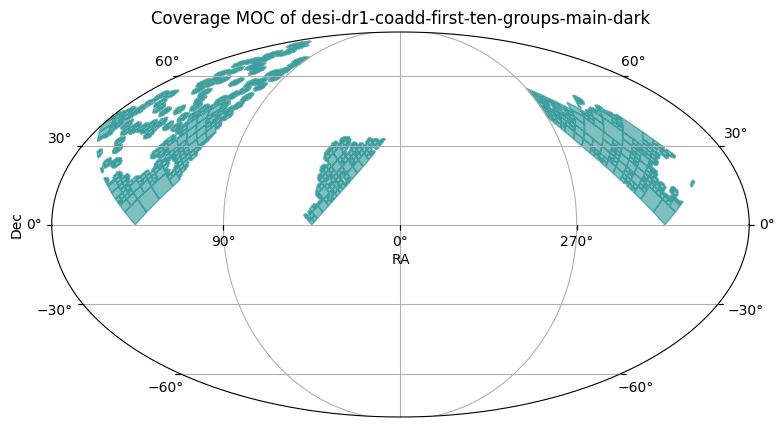

In [42]:
test_cat_target_groups.plot_coverage()

## Run the pipeline for all files

### Estimate best pixel threshold

  
We could use the `byte_pixel_threshold` argument, but because the rows appear to be of fixed size
(the nested spectra have same number of nested rows in each row), it would be faster to do a row count threshold.

Let's follow the [guide in hats-import](https://hats-import.readthedocs.io/en/stable/notebooks/estimate_pixel_threshold.html):

In [ ]:
import os
import pyarrow.parquet as pq

test_dr1_catalog = output_path / "desi-dr1-coadd-test"
sample_parquet_file = test_dr1_catalog / "dataset" / "Norder=5" / "Dir=0" / "Npix=0.parquet"

sample_file_size = os.path.getsize(sample_parquet_file)
parquet_file = pq.ParquetFile(sample_parquet_file)
num_rows = parquet_file.metadata.num_rows

## 300MB
ideal_file_small = 300 * 1024 * 1024
## 1G
ideal_file_large = 1024 * 1024 * 1024

threshold_small = ideal_file_small / sample_file_size * num_rows
threshold_large = ideal_file_large / sample_file_size * num_rows

print(f"threshold between {int(threshold_small):_} and {int(threshold_large):_}")

### Run the pipeline

In [43]:
import glob

all_files = sorted(glob.glob(f'{base_path}/main/dark/*/*/coadd-main-dark-*.fits'))
print(f"Found {len(all_files)} coadd files")

Found 13494 coadd files


In [44]:
# Hang on--how many groups are there, after all? The glossary says there should only be 100...

# set([file.split("dark/")[1].split("/")[0] for file in all_files_in_target_groups])
len(set([file.split("dark/")[1].split("/")[0] for file in all_files]))

223

In [ ]:
print(f"Writing catalog to {output_path}...")

args = ImportArguments(
    input_file_list=all_files,
    file_reader=DesiCoaddReader(),
    ra_column='TARGET_RA',
    dec_column='TARGET_DEC',
    output_artifact_name='desi-dr1-coadd-main-dark',
    output_path=output_path,
    pixel_threshold=10_000,  # Selected based on prior section
    resume=True,
)

with Client(n_workers=8, threads_per_worker=1) as client:
    pipeline_with_client(args, client)

In [ ]:
"""
!tree $output_path

/global/cfs/cdirs/cosmo/users/olynn
├── desi-dr1-coadd-main-dark
│   └── intermediate
│       ├── input_paths.txt
│       ├── mapping_done
│       ├── reader.pickle
│       ├── reducing
│       ├── row_count_histograms
│       │   ├── map_0.npz
│       │   ├── map_10000.npz
│       │   ├── map_10001.npz
...
"""

# target_file = output_path / "desi-dr1-coadd-main-dark" / "intermediate" / "row_count_histograms" / "map_10000.npz"
for file_name in [
    "map_0.npz",
    "map_10000.npz",
    "map_10001.npz",
]:
    target_file = output_path / "desi-dr1-coadd-main-dark" / "intermediate" / "row_count_histograms" / file_name
    histogram_data = np.load(target_file)
    # NpzFile '/global/cfs/cdirs/cosmo/users/olynn/desi-dr1-coadd-main-dark/intermediate/row_count_histograms/map_10000.npz' with keys: indexes, counts, order
    indexes = histogram_data['indexes']
    counts = histogram_data['counts']
    order = histogram_data['order']
    plt.bar(indexes, counts)
    plt.xlabel('Pixel Index')
    plt.ylabel('Row Count')
    plt.title(f'Row Count Distribution for {file_name} (Order {order})')
    plt.show()

In [ ]:
from hats_import.catalog.resume_plan import ResumePlan
import hats_import.file_io as import_io
from hats.pixel_math.sparse_histogram import HistogramAggregator, SparseHistogram

resume_plan = ResumePlan(import_args=args)

In [ ]:
# Throws error:
# Check total rows matches expectation.
# raw_histogram_row_count = resume_plan.read_histogram(
#     args.mapping_healpix_order, which_histogram="row_count"
# )

self = resume_plan
healpix_order = args.mapping_healpix_order
which_histogram="row_count"

# read_histogram function:
if which_histogram == "row_count":
    histogram_binary_file = self.ROW_COUNT_HISTOGRAM_BINARY_FILE
    histogram_directory = self.ROW_COUNT_HISTOGRAMS_DIR
# elif which_histogram == "mem_size" and self.threshold_mode == "mem_size":
#     histogram_binary_file = self.MEM_SIZE_HISTOGRAM_BINARY_FILE
#     histogram_directory = self.MEM_SIZE_HISTOGRAMS_DIR
# elif which_histogram == "mem_size":
#     raise ValueError("Cannot read mem_size histogram when threshold_mode is not 'mem_size'.")
# else:
#     raise ValueError(f"Unrecognized which_histogram value: {which_histogram}")

file_name = import_io.append_paths_to_pointer(self.tmp_path, histogram_binary_file)

# If no file, read the histogram from partial histograms and combine.
if not file_name.exists():
    remaining_map_files = self.get_remaining_map_keys(which_histogram=which_histogram)
    if len(remaining_map_files) > 0:
        raise RuntimeError(f"{len(remaining_map_files)} map stages did not complete successfully.")
    histogram_files = import_io.find_files_matching_path(self.tmp_path, histogram_directory, "*.npz")
    aggregate_histogram = HistogramAggregator(healpix_order)
    for partial_file_name in histogram_files:
        partial = SparseHistogram.from_file(partial_file_name)
        aggregate_histogram.add(partial)


In [ ]:
partial_file_name

target_file = output_path / "desi-dr1-coadd-main-dark" / "intermediate" / "row_count_histograms" / partial_file_name.name
histogram_data = np.load(target_file)
# NpzFile '/global/cfs/cdirs/cosmo/users/olynn/desi-dr1-coadd-main-dark/intermediate/row_count_histograms/map_10000.npz' with keys: indexes, counts, order
indexes = histogram_data['indexes']
counts = histogram_data['counts']
order = histogram_data['order']
plt.bar(indexes, counts)
plt.xlabel('Pixel Index')
plt.ylabel('Row Count')
plt.title(f'Row Count Distribution for {file_name} (Order {order})')
plt.show()

### Add default columns to the properties

(Oops, we could have done this in the ImportArguments with `addl_hats_properties={"hats_cols_default": "id, mjd", "obs_regime": "Optical"},`...)

### Check the catalog